# Panel

Some questions need two charts in one coordinate space: measurements against the model that should explain them, a count against a rate, an event against its background. A panel overlays figures already drawn by the chart functions of the [datachart.charts](../../../references/charts/) module (any chart from the [Charts](../../charts/) guides) and redraws them on a shared x-axis with up to two y-axes, so they read against each other. Where the [Grid](../grid/) keeps every figure in a coordinate space of its own, the panel merges them: reach for a grid to compare charts side by side, and for a panel to overlay them. This guide shows how to build panels with the [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) function, starting with the basics and building up to worked examples.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-panel), which maps common tasks to the parameter or per-figure option that does the job.

In [1]:
from datachart.charts import BarChart, LineChart
from datachart.utils import Panel

## Basics

The examples in this guide share one dataset: the monthly climate normals of Ljubljana's weather station, the mean temperature (in °C) and the total precipitation (in mm) of each month, rounded from the published 1991–2020 values. Plotted together they form a *climograph*, the standard chart of a climate and a panel by nature: precipitation as bars, temperature as a line, each on its own value axis. The data lives in a hidden cell.

In [2]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# mean monthly temperature in °C
TEMPERATURE = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# total monthly precipitation in mm
PRECIPITATION = [69, 70, 88, 99, 109, 144, 115, 137, 147, 147, 130, 107]

precipitation_data = [
    {"label": month, "y": value} for month, value in zip(MONTHS, PRECIPITATION)
]
temperature_data = [{"x": i, "y": value} for i, value in enumerate(TEMPERATURE)]

A panel overlays figures, so the first step is to draw each chart on its own. The precipitation is a bar chart with one labeled bar per month; the temperature is a line chart whose `x` values are the month indices, so its points land on the bars. The `subtitle` of each chart becomes its label in the panel legend:

In [3]:
precipitation = BarChart(data=precipitation_data, subtitle="Precipitation (mm)")
temperature = LineChart(data=temperature_data, subtitle="Temperature (°C)")

**Basic example.** Only the list of figures is required. The figures are drawn in the order given, the months of the bar chart label the shared x-axis, and the value axes are assigned automatically: the temperature spans about 20 units and the precipitation about 80, so the temperature moves to a second axis on the right. The [Axis assignment](#axis-assignment) section explains the rule and how to override it.

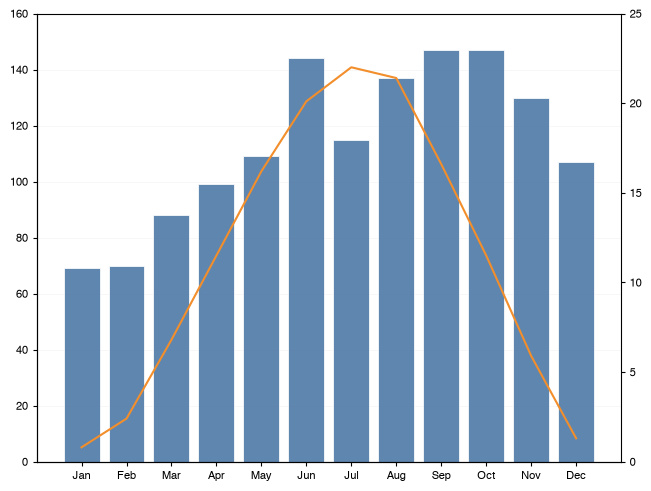

In [4]:
Panel(
    # add the figures to the panel
    [precipitation, temperature]
).show()

## Customizing the Panel

Every customization is either a keyword argument of `Panel` or a per-figure option of the dictionary wrapping a figure. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                 | See |
| :------------------------------------------ | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel_left`, `ylabel_right`                    | [Title and axis labels](#title-and-axis-labels) |
| resize the figure                           | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                         | [Figure size and grid](#figure-size-and-grid) |
| show which figure is which                  | `show_legend`, the charts' `subtitle`, per-figure `"legend_label"`  | [Legend](#legend) |
| title and place the legend                  | `legend`                                                            | [Legend](#legend) |
| put a figure on the right value axis        | per-figure `"y_axis"`                                               | [Axis assignment](#axis-assignment) |
| tune the automatic axis assignment          | `auto_secondary_axis`                                               | [Axis assignment](#axis-assignment) |
| bring a figure to the front                 | per-figure `"z_order"`                                              | [Drawing order](#drawing-order) |
| highlight one figure, mute the rest         | per-figure `"emphasis"`                                             | [Emphasis](#emphasis) |
| limit the axes                              | `xmin`, `xmax`, `ymin`, `ymax`, `ymin_right`, `ymax_right`          | [Axis limits](#axis-limits) |
| scale an axis (linear, log, …)              | `scalex`, `scaley`, `scaley_right`, or the charts' own `scaley`     | [Axis scales](#axis-scales) |
| overlay several bar charts                  | `bar_mode`                                                          | [Bar mode](#bar-mode) |
| add a figure to an existing panel           | nest `Panel` figures                                                | [Nesting panels](#nesting-panels) |
| overlay horizontal bars                     | `orientation` on the bar charts, the same `Panel` parameters        | [Horizontal panels](#horizontal-panels) |
| change the defaults of every panel          | `config.update_config` with the `overlay_*` settings                | [Panel configuration](#panel-configuration) |
| save the panel to a file                    | `save_figure`                                                       | [Saving Figures](../saving/) guide |

The full list of parameters and per-figure options is in the [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) reference. The look of each figure (colors, line widths, markers) is set on the chart itself through its `style` attribute; see the guide of each chart in the [Charts](../../charts/) section.

### Title and axis labels

Two value axes need two labels, or the reader cannot tell which scale a mark is read against. `title` names the panel, `xlabel` the shared axis, and `ylabel_left` and `ylabel_right` the two value axes; `ylabel_right` is only drawn when a figure sits on the right axis.

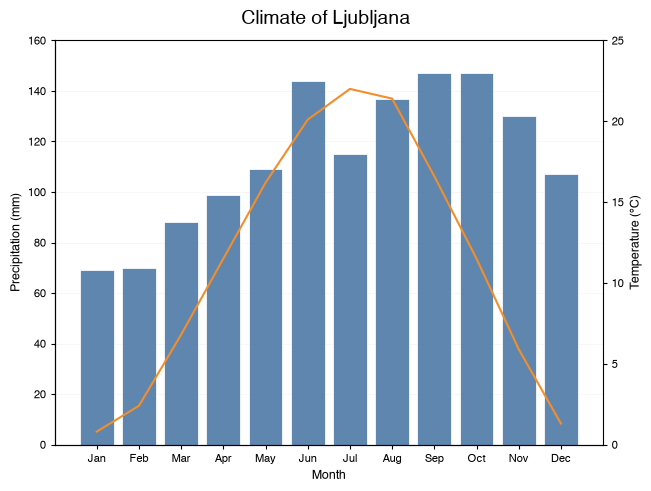

In [5]:
Panel(
    [precipitation, temperature],
    # add the title
    title="Climate of Ljubljana",
    # add the x and y axis labels, one per value axis
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
).show()

### Figure size and grid

A panel is usually the centerpiece of a page, and it should be sized like one. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE); the panel owns its figure size, whatever the sizes of the figures it overlays. Grid lines let the eye carry a mark across to an axis, and with two value axes they can only follow one, the left: `show_grid` draws them with a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member.

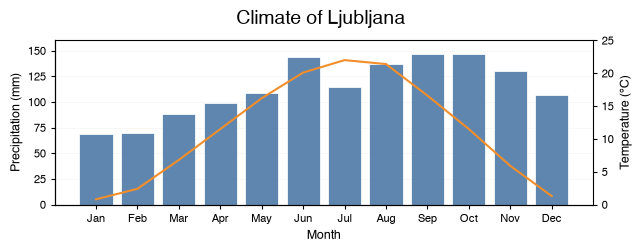

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

Panel(
    [precipitation, temperature],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the left value axis
    show_grid=SHOW_GRID.Y,
).show()

### Legend

Overlaid figures need a legend more than any single chart does, because nothing else says which mark is which. `show_legend` merges the entries of every figure, labeled by the `subtitle` of its chart, and when the panel has two value axes an `(L)` or `(R)` suffix says which axis an entry is read against. A figure that should be labeled differently in the panel than on its own is wrapped in a dictionary with a `"legend_label"`, which overrides its subtitle. `legend` then says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols` and the `alignment` of the entries ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)); the axis labels already carry the units, so the legend labels can drop them.

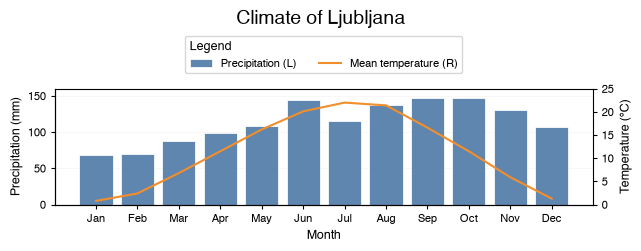

In [7]:
from datachart.constants import LEGEND_LOCATION

Panel(
    [
        # override the subtitle of each chart in the legend
        {"figure": precipitation, "legend_label": "Precipitation"},
        {"figure": temperature, "legend_label": "Mean temperature"},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # show the legend, in one row above the axes
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 2},
).show()

### Axis assignment

Two quantities in different units cannot share a scale without one of them flattening out, which is what the second value axis is for. Each figure takes its axis from the per-figure `"y_axis"` option: `"left"`, `"right"`, or `"auto"`, the default, where the panel compares the span of each figure's values and separates figures whose spans differ by more than the `auto_secondary_axis` ratio (default `3.0`), the larger group on the left. The temperature spans about 20 units and the precipitation about 80, a ratio of about 4, which is why the [basic example](#basics) already has two axes. An explicit `"y_axis"` is the robust choice whenever you know which axis a figure belongs to: the data can change, the assignment should not.

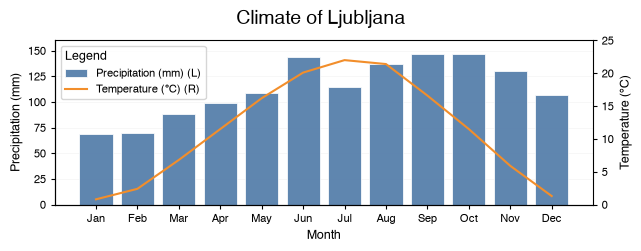

In [8]:
Panel(
    [
        # assign each figure to its value axis explicitly
        {"figure": precipitation, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

`auto_secondary_axis` keeps the automatic assignment but makes it more or less eager. A ratio above the 4 of this dataset keeps both figures on the left axis, where the temperature is squeezed against the bottom, which is the reason the panel splits the axes in the first place:

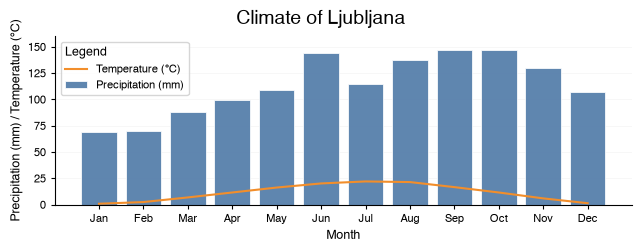

In [9]:
Panel(
    [precipitation, temperature],
    # only split the axes when the spans differ more than tenfold
    auto_secondary_axis=10.0,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm) / Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Drawing order

A line read against bars must not disappear behind them. The figures are drawn in the order given, later ones on top, and when no order is given each chart type takes the default of its kind from the [panel configuration](#panel-configuration): bars and histograms sit behind lines and scatter points. The per-figure `"z_order"` option overrides that, higher values on top, whatever the position in the list. The example reverses the default and draws the bars over the line, which is how a bar chart hides a line and why the default is the other way round.

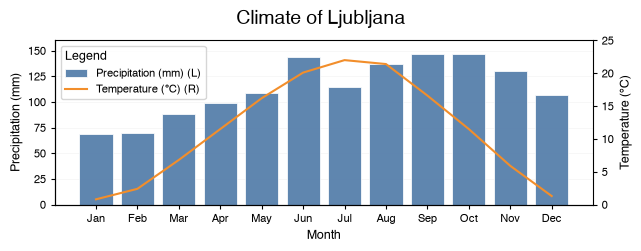

In [10]:
Panel(
    [
        # draw the bars on top of the line
        {"figure": precipitation, "y_axis": "left", "z_order": 2},
        {"figure": temperature, "y_axis": "right", "z_order": 1},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Emphasis

In most overlays one figure is the message and the others are context, and emphasis says which is which. The per-figure `"emphasis"` option applies one role to every layer of a figure: `"background"` mutes it (the muted color of the active theme, pushed behind the others, dropped from the legend), `"highlight"` bolds it and brings it to the front of the data layers, and `None` leaves it as it is. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across the package. Here the precipitation is context and the temperature the message:

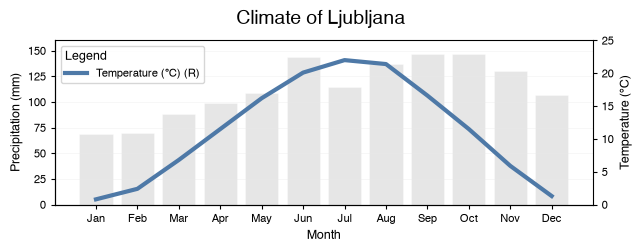

In [11]:
from datachart.constants import EMPHASIS

Panel(
    [
        # mute the bars, bold the line
        {"figure": precipitation, "y_axis": "left", "emphasis": EMPHASIS.BACKGROUND},
        {"figure": temperature, "y_axis": "right", "emphasis": EMPHASIS.HIGHLIGHT},
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Axis limits

Two value axes tempt the eye to compare heights across them, and the honest way to allow that is to start both at zero. `ymin` and `ymax` set the left axis, `ymin_right` and `ymax_right` the right one, and `xmin` and `xmax` the shared axis; limits set on the individual charts are not carried over, the panel owns its axes. With labeled bars the x positions are the indices of the labels, so half-integer limits cut between two months. The example zooms in on April to September and starts both value axes at zero, which also leaves room for the legend:

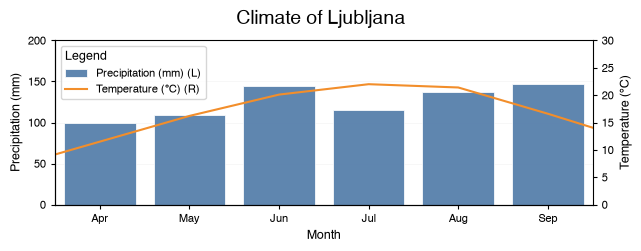

In [12]:
Panel(
    [
        {"figure": precipitation, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    # zoom in on April to September
    xmin=2.5,
    xmax=8.5,
    # start both value axes at zero
    ymin=0,
    ymax=200,
    ymin_right=0,
    ymax_right=30,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Axis scales

A quantity that spans orders of magnitude next to one that does not is the case for two axes with two scales. `scalex`, `scaley` and `scaley_right` take a [SCALE](../../../references/constants/#datachart.constants.SCALE) member; `scaley` applies to the left value axis and `scaley_right` to the right one, so the two scale independently. Unlike the limits, a scale set on an individual chart is carried over: a chart drawn with `scaley=SCALE.LOG` stays log in the panel, on whichever axis it lands, and the panel attributes override it per axis. When figures sharing one axis were built with different scales, the first one wins and the panel warns; the `overlay_warn_scale_conflict` setting of the [panel configuration](#panel-configuration) switches the warning off.

`pollen` holds an illustrative monthly mean pollen concentration (in grains/m³), which spans three orders of magnitude between winter and spring. Against the precipitation bars on a linear left axis, a log right axis is what keeps the winter months readable:

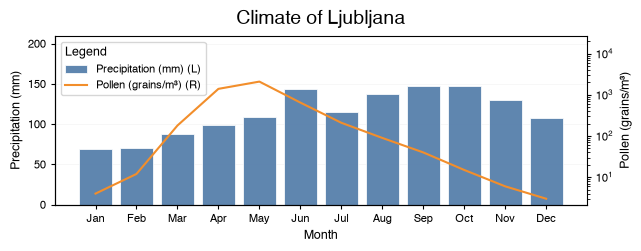

In [13]:
from datachart.constants import SCALE

# an illustrative monthly mean pollen concentration in grains/m³
POLLEN = [4, 12, 180, 1400, 2100, 650, 210, 90, 40, 15, 6, 3]
pollen = LineChart(
    data=[{"x": i, "y": value} for i, value in enumerate(POLLEN)],
    subtitle="Pollen (grains/m³)",
)

Panel(
    [
        {"figure": precipitation, "y_axis": "left"},
        {"figure": pollen, "y_axis": "right"},
    ],
    # a log scale on the right value axis only; the left one stays linear
    scaley_right=SCALE.LOG,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Pollen (grains/m³)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Bar mode

Several bar charts in one panel have to share each category somehow, and `bar_mode` says how ([BAR_MODE](../../../references/constants/#datachart.constants.BAR_MODE)): `"group"` draws the bars side by side (the default), `"stack"` stacks them so each stack is the total, `"overlay"` draws them over each other with transparency. The example splits the precipitation into the rain and the snow of each month (the split is illustrative) and stacks them, so the bars still add up to the monthly total while the temperature line stays on its own axis:

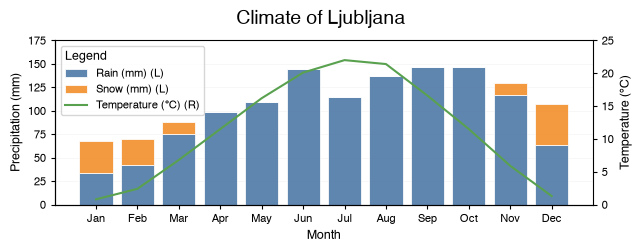

In [14]:
from datachart.constants import BAR_MODE

# an illustrative split of the monthly precipitation into snow (cold months) and rain
SNOW_SHARE = [0.5, 0.4, 0.15, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.4]
snow = BarChart(
    data=[
        {"label": month, "y": round(total * share)}
        for month, total, share in zip(MONTHS, PRECIPITATION, SNOW_SHARE)
    ],
    subtitle="Snow (mm)",
)
rain = BarChart(
    data=[
        {"label": month, "y": round(total * (1 - share))}
        for month, total, share in zip(MONTHS, PRECIPITATION, SNOW_SHARE)
    ],
    subtitle="Rain (mm)",
)

Panel(
    [
        {"figure": rain, "y_axis": "left"},
        {"figure": snow, "y_axis": "left"},
        {"figure": temperature, "y_axis": "right"},
    ],
    # stack the bars of the two bar charts
    bar_mode=BAR_MODE.STACK,
    # headroom above the tallest stack
    ymin=0,
    ymax=175,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Nesting panels

A panel built in one place often needs one more figure in another, and rebuilding it from its parts is a chore. Panel figures nest: `Panel([Panel([f1, f2]), f3])` is equivalent to `Panel([f1, f2, f3])`, to any depth. A nested panel contributes its figures with their per-figure options intact, while the panel-level settings (title, labels, limits) always come from the outermost call; the axis scales travel with the figures, as above. The stacked precipitation panel from the previous section, extended with the temperature:

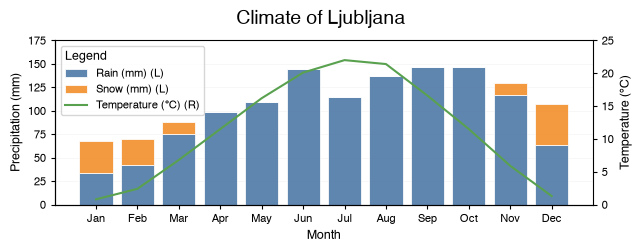

In [15]:
# an existing panel...
precipitation_panel = Panel(
    [
        {"figure": rain, "y_axis": "left"},
        {"figure": snow, "y_axis": "left"},
    ],
    bar_mode=BAR_MODE.STACK,
)

# ...later extended with an additional figure
Panel(
    [precipitation_panel, {"figure": temperature, "y_axis": "right"}],
    bar_mode=BAR_MODE.STACK,
    ymin=0,
    ymax=175,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Horizontal panels

Long category names read best on horizontal bars, and a panel follows the bars. A panel takes its orientation from the figures it holds: it is horizontal when every bar chart (and histogram) in it is horizontal, vertical otherwise, and mixing the two raises a `ValueError`. Line and scatter figures have no orientation of their own and follow the panel: in a horizontal panel their `x` runs along the categories and their `y` along the values, so the same temperature line overlays vertical and horizontal bars.

The parameters keep their names but address the axes by role. The *value axis* carries the quantities (x in a horizontal panel) and the *category axis* the labels (y): `ylabel_left`, `ylabel_right`, `ymin`, `ymax`, `ymin_right`, `ymax_right`, `scaley` and `scaley_right` refer to the value axes, `xlabel`, `xmin`, `xmax` and `scalex` to the category axis. The secondary value axis sits at the top, so `"y_axis": "right"` places a figure on the top axis and the legend marks the two with `(B)` and `(T)`. Only `show_grid` keeps its literal meaning; it names the gridlines you see.

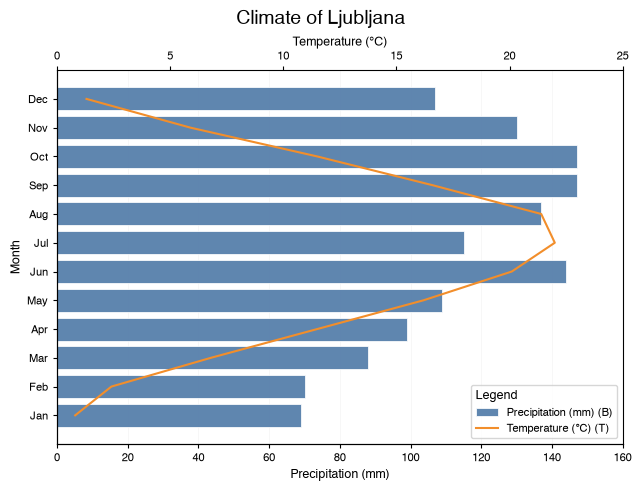

In [16]:
from datachart.constants import ORIENTATION

# horizontal bars make the panel horizontal
precipitation_h = BarChart(
    data=precipitation_data,
    subtitle="Precipitation (mm)",
    orientation=ORIENTATION.HORIZONTAL,
)

Panel(
    [
        {"figure": precipitation_h, "y_axis": "left"},
        # "right" is the top value axis in a horizontal panel
        {"figure": temperature, "y_axis": "right"},
    ],
    title="Climate of Ljubljana",
    # the category axis (y) and the two value axes (bottom and top)
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    # start both value axes at zero
    ymin=0,
    ymin_right=0,
    figsize=FIG_SIZE.FULL_MEDIUM,
    # gridlines keep their literal spelling: vertical lines along the values
    show_grid=SHOW_GRID.X,
    show_legend=True,
).show()

## Panel Configuration

The defaults the panel falls back on (the automatic axis threshold, the transparency of overlaid bars and histograms, the default drawing order of each chart type, the bar mode) are part of the global configuration, under the keys that start with `overlay_`. They are changed like any other setting, through [datachart.config.config.update_config](../../../references/config/#datachart.config.Config.update_config); see the [Themes](../../styling/themes/) guide for the configuration system as a whole. The current keys and their values in the active theme are:

In [17]:
from datachart.config import config

{key: value for key, value in config.config.items() if key.startswith("overlay_")}

{'overlay_auto_threshold': 3.0,
 'overlay_bar_alpha': 0.7,
 'overlay_hist_alpha': 0.6,
 'overlay_default_zorder_bar': 1,
 'overlay_default_zorder_line': 2,
 'overlay_default_zorder_scatter': 2,
 'overlay_default_zorder_hist': 1,
 'overlay_bar_mode': 'group',
 'overlay_warn_thin_bars': True,
 'overlay_warn_scale_groups': True,
 'overlay_warn_scale_conflict': True}

A setting given to `Panel` directly, such as `auto_secondary_axis` or `bar_mode`, always wins over the configuration. The configuration is the place for a default that should hold for every panel of a document:

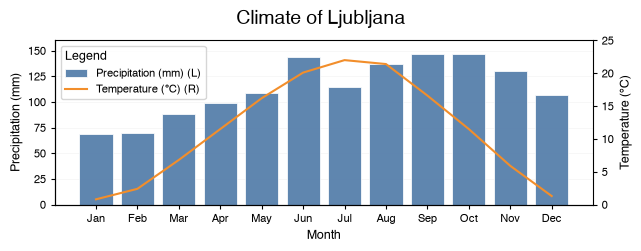

In [18]:
config.update_config(
    {
        # split the value axes sooner
        "overlay_auto_threshold": 2.0,
        # draw overlaid bars more transparent
        "overlay_bar_alpha": 0.5,
    }
)

Panel(
    [precipitation, temperature],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

# restore the defaults for the rest of the guide
config.reset_config()

## Real-World Examples

The examples below put the features above to work on real or realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from. The chart functions they overlay are imported as needed; any chart from the [Charts](../../charts/) guides can take part in a panel.

### Example 1: Does the Model Fit? (Measurements and a Fitted Curve on One Axis)

`observed` holds the illustrative reaction velocity of an enzyme at 15 substrate concentrations, drawn from the Michaelis–Menten equation with seeded measurement noise, and `model` the noise-free curve at 100 concentrations. The question every fit raises is how well the model explains the data, and the answer is visible only when the two are overlaid: the measurements as a scatter chart, the model as a line. They share the same units, so they share one value axis and the default `"auto"` assignment leaves it at that; the fitted parameters go in a note, which travels with the line.

In [19]:
import numpy as np

rng = np.random.RandomState(42)
# Michaelis-Menten parameters: maximum velocity and the Michaelis constant
V_MAX, K_M = 50, 20
substrate = np.linspace(0, 100, 15)
observed = [
    {"x": float(s), "y": float(V_MAX * s / (K_M + s) + rng.randn() * 2)}
    for s in substrate
]
curve = np.linspace(0, 100, 100)
model = [{"x": float(s), "y": float(V_MAX * s / (K_M + s))} for s in curve]

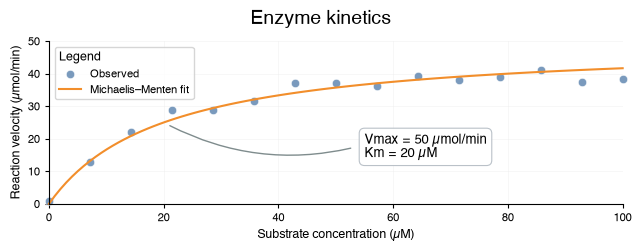

In [20]:
from datachart.charts import ScatterChart

Panel(
    [
        ScatterChart(data=observed, subtitle="Observed"),
        LineChart(
            data=model,
            subtitle="Michaelis–Menten fit",
            # the fitted parameters, pointing at the half-saturation point
            texts={
                "text": f"Vmax = {V_MAX} µmol/min\nKm = {K_M} µM",
                "x": 0.55,
                "y": 0.35,
                "coords": "axes",
                "target": (K_M, V_MAX / 2),
            },
        ),
    ],
    title="Enzyme kinetics",
    xlabel="Substrate concentration (µM)",
    ylabel_left="Reaction velocity (µmol/min)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.BOTH,
    show_legend=True,
).show()

### Example 2: Is the Sample Normal? (A Histogram and a Fitted Density)

`diameters` holds the illustrative diameter (in µm) of 250 cells measured under a microscope, drawn from a seeded normal generator, and `normal_fit` the normal density with the same mean and standard deviation, scaled to the bin width and the sample size so it is comparable with the histogram counts. Whether a sample is normally distributed is a question the histogram alone cannot settle; the fitted curve over it can. The curve is drawn on top of the histogram by default (histograms take the background drawing order) and reads against it on the same value axis.

In [21]:
rng = np.random.RandomState(42)
MEAN, STD, N_CELLS, N_BINS = 12.5, 2.3, 250, 25
measurements = rng.normal(MEAN, STD, N_CELLS)
diameters = [{"x": float(x)} for x in measurements]
# the normal density scaled to the histogram counts: N * bin width * pdf(x)
bin_width = (measurements.max() - measurements.min()) / N_BINS
grid = np.linspace(measurements.min(), measurements.max(), 150)
density = N_CELLS * bin_width * np.exp(-0.5 * ((grid - MEAN) / STD) ** 2) / (STD * np.sqrt(2 * np.pi))
normal_fit = [{"x": float(x), "y": float(y)} for x, y in zip(grid, density)]

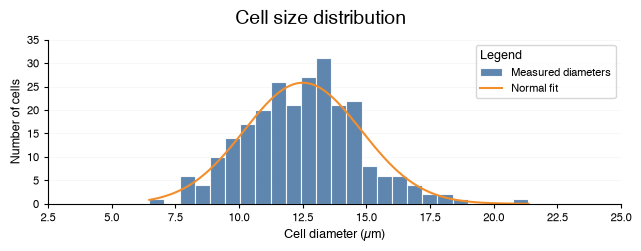

In [22]:
from datachart.charts import Histogram

Panel(
    [
        Histogram(data=diameters, num_bins=N_BINS, subtitle="Measured diameters"),
        LineChart(data=normal_fit, subtitle="Normal fit"),
    ],
    title="Cell size distribution",
    xlabel="Cell diameter (µm)",
    ylabel_left="Number of cells",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Example 3: Where Do the Returns Come From? (A Pareto Chart on Two Axes)

`returns` holds the illustrative reasons customers gave for returning orders in one quarter, with the number of returns per reason, and `cumulative` the running share of all returns once the reasons are ordered from most to least frequent. The question is which few reasons account for most of the returns, and the Pareto chart answers it: counts as bars on the left axis and the cumulative share as a line on the right one, which crosses the 80 % mark at the third reason. The bars are pre-sorted so the line's positions match them, the right axis is pinned to 0–100 % so the share reads like a percentage, and a note declared on the line chart names the answer.

In [23]:
# illustrative reasons for returned orders in one quarter, with the number of returns
RETURN_REASONS = {
    "Size": 412,
    "Damaged": 265,
    "Changed mind": 230,
    "Description": 101,
    "Late": 62,
    "Other": 40,
}
ordered = sorted(RETURN_REASONS.items(), key=lambda item: item[1], reverse=True)
total = sum(RETURN_REASONS.values())

returns = [{"label": reason, "y": count} for reason, count in ordered]
cumulative, running = [], 0
for i, (reason, count) in enumerate(ordered):
    running += count
    cumulative.append({"x": i, "y": round(100 * running / total, 1)})
VITAL_FEW = next(i for i, point in enumerate(cumulative) if point["y"] >= 80) + 1

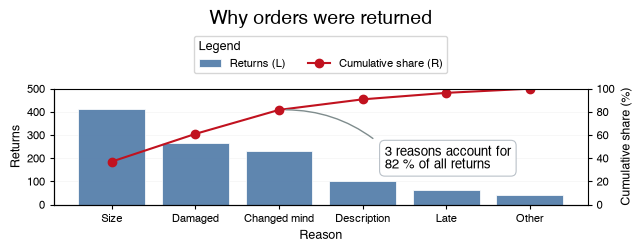

In [24]:
from datachart.constants import LINE_MARKER

counts = BarChart(data=returns, subtitle="Returns")
share = LineChart(
    data=cumulative,
    subtitle="Cumulative share",
    style={"plot_line_color": "#c1121f", "plot_line_marker": LINE_MARKER.CIRCLE},
    # the answer, pointing at the reason where the share passes 80 %
    texts={
        "text": f"{VITAL_FEW} reasons account for\n{cumulative[VITAL_FEW - 1]['y']:.0f} % of all returns",
        "x": 0.62,
        "y": 0.4,
        "coords": "axes",
        "target": (VITAL_FEW - 1, cumulative[VITAL_FEW - 1]["y"]),
    },
)

Panel(
    [
        {"figure": counts, "y_axis": "left"},
        {"figure": share, "y_axis": "right"},
    ],
    title="Why orders were returned",
    xlabel="Reason",
    ylabel_left="Returns",
    ylabel_right="Cumulative share (%)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 2},
    ymin=0,
    ymin_right=0,
    ymax_right=100,
).show()

### Example 4: What Stands Out From the Background? (Emphasis and One Scale for Everything)

`baseline` holds 200 minutes of illustrative ground acceleration (in g) of a seismometer at rest, drawn from a seeded generator, and `tremor` and `earthquake` two events, a minor tremor and a larger earthquake, as bell-shaped bursts over the same baseline. The baseline is context: the `"background"` emphasis mutes it and drops it from the legend, so the two events, each in its own chart and color, are what the reader sees. The events dwarf the baseline (a span ratio of about 12), so the default axis assignment would move the baseline to its own axis and blow it up; raising `auto_secondary_axis` above that ratio keeps every figure on one scale, the whole point being that the events stand out against the baseline.

In [25]:
rng = np.random.RandomState(42)
REST = 0.02
baseline = [{"x": t, "y": float(REST + rng.randn() * 0.005)} for t in range(200)]


def event(center, width, peak, noise, span):
    # a bell-shaped burst of ground acceleration around `center`
    return [
        {"x": t, "y": float(REST + peak * np.exp(-0.5 * ((t - center) / width) ** 2) + rng.randn() * noise)}
        for t in range(*span)
    ]


tremor = event(center=45, width=3, peak=0.15, noise=0.01, span=(35, 55))
earthquake = event(center=140, width=4, peak=0.35, noise=0.015, span=(128, 152))

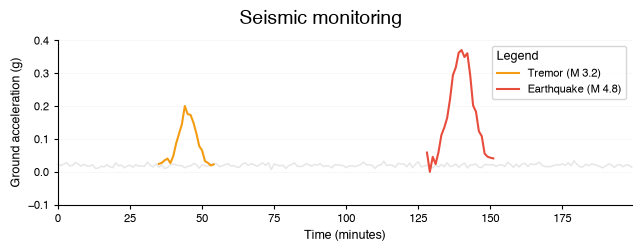

In [26]:
Panel(
    [
        # the baseline is context: mute it
        {"figure": LineChart(data=baseline, subtitle="Background"), "emphasis": EMPHASIS.BACKGROUND},
        LineChart(data=tremor, subtitle="Tremor (M 3.2)", style={"plot_line_color": "#f39c12"}),
        LineChart(data=earthquake, subtitle="Earthquake (M 4.8)", style={"plot_line_color": "#e74c3c"}),
    ],
    # one scale for everything, so the events stand out against the baseline
    auto_secondary_axis=20.0,
    title="Seismic monitoring",
    xlabel="Time (minutes)",
    ylabel_left="Ground acceleration (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()